# Non-mammal cell-type mapping — SAMap, reciprocal best hit

Clean pipeline for the non-mammalian consensus cell types, distilled from
`Nonmam_Mapping_SAMap.ipynb` after comparing variants. Rules, in short:

- **SAMap only** — no SATURN.
- **Best hits ranked over eligible partners only.** SAMap's mapping table contains every label,
  including Allen/mouse-matched subclasses and `Unlabeled`. Ranking over all of them made ~49% of
  best hits point at types that can never be nodes; those calls were then silently dropped. Here
  the table is restricted to graph nodes *before* the argmax, so each type's best hit is the best
  partner that can actually form an edge.
- **Reciprocal best hit**, with a SAMap score floor of `THRESH` (0.1).
- **Label** `ss_subclass_v4_nounlabeled_nn`; consensus written to `ss_subclass_nounlabeled_nmm_v4_nn`.
- **Neurons only** — non-neuronal subclasses are suffixed `NN`. Nodes are species-specific clusters
  (`cj_1`, `dr_31`); Allen-labeled, `Unlabeled` and mouse-merged `xx_mNNN_mNNN` types are excluded.

The mapping table is symmetric: `score(u,v)` and `score(v,u)` read the same cell of the same block,
so the threshold is a single test, not one per direction.

Section 2 reuses `nonmam_samap_blocks_{DATE}.pkl` if present and only touches the 7-12 GB SAMap
pickles when it has to.

In [1]:
from samap.mapping import SAMAP
from samap.analysis import get_mapping_scores
from samap.utils import save_samap, load_samap
from samalg import SAM

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx
import anndata as ad

from collections import defaultdict
import itertools, os, gc, pickle

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [6]:
LEVEL     = 'ss_subclass_v4_nounlabeled_nn'      # input cell-type label
OUT_LEVEL = 'ss_subclass_nounlabeled_nmm_v4_nn'  # consensus column written back
THRESH    = 0.2                                 # SAMap score floor
DATE      = '07222026'

SAM_DIR   = 'Active_SAM_joined/'
SAMAP_DIR = 'Active_SAMap_Joined/active_samap/Non-mammal/'
BLOCKS    = f'nonmam_samap_blocks_{DATE}.pkl'    # cached mapping-table blocks

H5AD = {
    'cj': SAM_DIR + 'SAM_CJ_joined_v2_cleaned_03122025.h5ad',
    'ac': SAM_DIR + 'SAM_AC_ncbi_soupx_cleaned_03122025.h5ad',
    'xt': SAM_DIR + 'SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad',
    'dr': SAM_DIR + 'SAM_DR_ncbi_joined_cleaned_07172026.h5ad',
}

PAIRS = {
    ('cj', 'ac'): SAMAP_DIR + 'sm_cj_ac_ncbi_cleaned_03262025.pkl',
    ('cj', 'xt'): SAMAP_DIR + 'sm_cj_xt_cleaned_03262025.pkl',
    ('cj', 'dr'): SAMAP_DIR + 'sm_cj_v2_cleaned_dr_cleaned_07172026.pkl',
    ('ac', 'xt'): SAMAP_DIR + 'sm_ac_ncbi_xt_cleaned_03262025.pkl',
    ('ac', 'dr'): SAMAP_DIR + 'sm_ac_cleaned_dr_cleaned_07172026.pkl',
    ('xt', 'dr'): SAMAP_DIR + 'sm_xt_cleaned_dr_cleaned_07172026.pkl',
}

SPECIES      = ['cj', 'ac', 'xt', 'dr']   # also the prefix order used in group names
PREFIX_COLOR = {'cj': 'red', 'ac': 'blue', 'xt': 'green', 'dr': 'purple'}

print('cached blocks:', 'found' if os.path.exists(BLOCKS) else 'absent (section 2 will rebuild)')
for f in list(H5AD.values()) + list(PAIRS.values()):
    print(('OK   ' if os.path.exists(f) else 'MISS '), f)

cached blocks: found
OK    Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad
OK    Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad
OK    Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad
OK    Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad
OK    Active_SAMap_Joined/active_samap/Non-mammal/sm_cj_ac_ncbi_cleaned_03262025.pkl
OK    Active_SAMap_Joined/active_samap/Non-mammal/sm_cj_xt_cleaned_03262025.pkl
OK    Active_SAMap_Joined/active_samap/Non-mammal/sm_cj_v2_cleaned_dr_cleaned_07172026.pkl
OK    Active_SAMap_Joined/active_samap/Non-mammal/sm_ac_ncbi_xt_cleaned_03262025.pkl
OK    Active_SAMap_Joined/active_samap/Non-mammal/sm_ac_cleaned_dr_cleaned_07172026.pkl
OK    Active_SAMap_Joined/active_samap/Non-mammal/sm_xt_cleaned_dr_cleaned_07172026.pkl


## 1. Labels and node set

A label becomes a node if it is prefixed with its own species code, is not a mouse-merged `xx_m…`
type, and does not end in `NN`.

In [7]:
labels = {}   # species -> Series indexed by barcode

for s in SPECIES:
    a = ad.read_h5ad(H5AD[s], backed='r')
    labels[s] = a.obs[LEVEL].astype(str)
    print(f'{s}: {a.n_obs} cells, {labels[s].nunique()} distinct labels')
    del a

cj: 74758 cells, 139 distinct labels
ac: 47900 cells, 131 distinct labels
xt: 42221 cells, 122 distinct labels
dr: 61430 cells, 63 distinct labels


In [8]:
def is_neuronal(item):
    """Non-neuronal subclasses are suffixed NN, e.g. '326 OPC NN'."""
    return not item.endswith('NN')


def is_species_cluster(item, prefix):
    """cj_1 -> True; cj_m066_m067 -> False; '128 VMH Fezf1 Glut' / 'Unlabeled' -> False"""
    return len(item) > 3 and item[:2] == prefix and item[2] == '_' and item[3] != 'm'


node_species = {}
for s in SPECIES:
    own = [i for i in labels[s].unique() if is_species_cluster(i, s)]
    keep = [i for i in own if is_neuronal(i)]
    node_species.update({i: s for i in keep})
    print(f'{s}: {len(keep)} neuronal nodes '
          f'(dropped {len(own) - len(keep)} NN: {sorted(set(own) - set(keep))})')

cell_counts = {n: int(labels[node_species[n]].value_counts().get(n, 0)) for n in node_species}
print('\ntotal nodes:', len(node_species))

cj: 35 neuronal nodes (dropped 0 NN: [])
ac: 31 neuronal nodes (dropped 0 NN: [])
xt: 39 neuronal nodes (dropped 0 NN: [])
dr: 28 neuronal nodes (dropped 0 NN: [])

total nodes: 133


## 2. Mapping-table blocks

One block per pair: rows = species `b` types, columns = species `a` types, restricted to graph
nodes. Cached to `BLOCKS` — the SAMap pickles are only loaded if the cache is missing.

In [9]:
def eligible(block):
    return block.loc[[i for i in block.index   if i[3:] in node_species],
                     [c for c in block.columns if c[3:] in node_species]]


def compute_blocks():
    """Load each SAMap object once and keep the node-restricted score block."""
    out = {}
    for (a, b), path in PAIRS.items():
        print(f'=== {a} vs {b} : {os.path.basename(path)}')
        sm = load_samap(path)
        for org in (a, b):
            if LEVEL not in sm.sams[org].adata.obs.columns:
                raise KeyError(f'{org}: {LEVEL} missing from {os.path.basename(path)}')

        D, MappingTable = get_mapping_scores(sm, {a: LEVEL, b: LEVEL})
        full = MappingTable.loc[[i for i in MappingTable.index   if i[:2] == b],
                                [i for i in MappingTable.columns if i[:2] == a]]
        out[(a, b)] = eligible(full)
        print(f'    {full.shape} -> eligible {out[(a, b)].shape}')

        del sm, D, MappingTable, full
        gc.collect()
    return out


if os.path.exists(BLOCKS):
    with open(BLOCKS, 'rb') as fh:
        cached = pickle.load(fh)
    blocks = cached['eligible'] if isinstance(cached, dict) and 'eligible' in cached else cached
    print(f'loaded {len(blocks)} blocks from {BLOCKS}')
else:
    blocks = compute_blocks()
    with open(BLOCKS, 'wb') as fh:
        pickle.dump({'eligible': blocks}, fh)
    print(f'saved {BLOCKS}')

for k, v in sorted(blocks.items()):
    print(f'  {k}: {v.shape}')

loaded 6 blocks from nonmam_samap_blocks_07222026.pkl
  ('ac', 'dr'): (28, 31)
  ('ac', 'xt'): (39, 31)
  ('cj', 'ac'): (31, 35)
  ('cj', 'dr'): (28, 35)
  ('cj', 'xt'): (39, 35)
  ('xt', 'dr'): (28, 39)


## 3. Best hits among eligible partners

`idxmax` over the node-only block, so every recorded partner is one that can form an edge.

In [10]:
def best_hits_from(block):
    out = {}
    for col in block.columns:
        item = col[3:]
        if block[col].isna().all() or block[col].max() == 0:
            out[item] = [None, 0.0]
            continue
        best = block[col].idxmax()
        out[item] = [best[3:], float(block.loc[best, col])]
    return out


mapping_frames = {}
for (a, b), blk in blocks.items():
    for (src, dst), d in (((a, b), best_hits_from(blk)), ((b, a), best_hits_from(blk.T))):
        df = pd.DataFrame.from_dict(d, orient='index',
                                    columns=['SAMAP match', 'SAMAP score'])
        df.index.name = 'source'
        fn = f'{src}_{dst}_nonmam_mapping_SAMap_{DATE}.csv'
        df.to_csv(fn)
        mapping_frames[(src, dst)] = df
        print(f'{fn}  ({len(df)} types, '
              f'{int((df["SAMAP score"] >= THRESH).sum())} at or above {THRESH})')

cj_ac_nonmam_mapping_SAMap_07222026.csv  (35 types, 12 at or above 0.2)
ac_cj_nonmam_mapping_SAMap_07222026.csv  (31 types, 13 at or above 0.2)
cj_xt_nonmam_mapping_SAMap_07222026.csv  (35 types, 14 at or above 0.2)
xt_cj_nonmam_mapping_SAMap_07222026.csv  (39 types, 12 at or above 0.2)
cj_dr_nonmam_mapping_SAMap_07222026.csv  (35 types, 8 at or above 0.2)
dr_cj_nonmam_mapping_SAMap_07222026.csv  (28 types, 4 at or above 0.2)
ac_xt_nonmam_mapping_SAMap_07222026.csv  (31 types, 15 at or above 0.2)
xt_ac_nonmam_mapping_SAMap_07222026.csv  (39 types, 14 at or above 0.2)
ac_dr_nonmam_mapping_SAMap_07222026.csv  (31 types, 9 at or above 0.2)
dr_ac_nonmam_mapping_SAMap_07222026.csv  (28 types, 6 at or above 0.2)
xt_dr_nonmam_mapping_SAMap_07222026.csv  (39 types, 12 at or above 0.2)
dr_xt_nonmam_mapping_SAMap_07222026.csv  (28 types, 10 at or above 0.2)


## 4. Edges: reciprocal best hit ≥ THRESH

In [11]:
G = nx.Graph()
G.add_nodes_from(node_species)
rejected = defaultdict(list)

for (a, b) in PAIRS:
    for (src, dst) in ((a, b), (b, a)):
        fwd, rev = mapping_frames[(src, dst)], mapping_frames[(dst, src)]
        for u, row in fwd.iterrows():
            v = row['SAMAP match']
            if not isinstance(v, str) or v not in rev.index:
                rejected['no partner'].append(u)
                continue
            score = float(row['SAMAP score'])
            if rev.loc[v, 'SAMAP match'] != u:
                rejected['not mutual'].append((u, v, round(score, 3)))
                continue
            if score < THRESH:
                rejected['below threshold'].append((u, v, round(score, 3)))
                continue
            G.add_edge(u, v, weight=score)

print(f'edges: {G.number_of_edges()}')
for k, v in rejected.items():
    print(f'  rejected, {k}: {len(v)}')

edges: 50
  rejected, not mutual: 240
  rejected, below threshold: 54
  rejected, no partner: 5


In [12]:
pd.DataFrame([{'A': u, 'B': v, 'score': round(d['weight'], 3)}
               for u, v, d in G.edges(data=True)]).sort_values('score', ascending=False)

,A,B,score
35,ac_34,xt_31,0.913
22,cj_12,ac_27,0.847
36,ac_30,xt_38,0.798
42,xt_12,dr_27,0.660
24,cj_17,ac_9,0.647
2,cj_7,ac_17,0.645
47,xt_37,dr_7,0.602
13,cj_16,ac_6,0.592
4,cj_6,xt_18,0.572
23,cj_12,dr_0,0.572


## 5. Consensus groups

Connected components become homology groups, named for the species present in `cj, ac, xt, dr`
order plus a counter (`cj_ac_xt_1`). Types in no group keep their original label.

In [14]:
def name_groups(g):
    comps = [c for c in nx.connected_components(g) if len(c) > 1]
    counters = defaultdict(int)
    res, members = {}, {}
    for c in sorted(comps, key=len, reverse=True):
        combo = '_'.join(sorted({node_species[n] for n in c}, key=SPECIES.index))
        counters[combo] += 1
        name = f'{combo}_{counters[combo]}'
        members[name] = sorted(c)
        for n in c:
            res[n] = name
    return res, members


result, members = name_groups(G)
print(f'{len(members)} groups covering {len(result)} of {len(node_species)} types\n')

for name, mem in sorted(members.items(), key=lambda kv: -len(kv[1])):
    counts = {s: sum(1 for n in mem if node_species[n] == s) for s in SPECIES}
    dup = ', '.join(f'{s}x{counts[s]}' for s in SPECIES if counts[s] > 1)
    print(f'=== {name}   {len(mem)} types, {sum(cell_counts[n] for n in mem)} cells'
          + (f'   [DUPES: {dup}]' if dup else ''))
    for n in sorted(mem):
        nbrs = sorted(G[n].items(), key=lambda kv: -kv[1]['weight'])
        print(f"    {n:<8} {cell_counts[n]:>6} cells   -> "
              + ', '.join(f"{m}={d['weight']:.2f}" for m, d in nbrs))
    print()

21 groups covering 67 of 133 types

=== cj_ac_xt_dr_1   7 types, 9207 cells   [DUPES: cjx2, acx3]
    ac_1       1481 cells   -> cj_1=0.54, xt_1=0.53
    ac_23       103 cells   -> dr_0=0.38
    ac_27        75 cells   -> cj_12=0.85
    cj_1       1025 cells   -> ac_1=0.54, xt_1=0.47
    cj_12       321 cells   -> ac_27=0.85, dr_0=0.57
    dr_0       5329 cells   -> cj_12=0.57, ac_23=0.38, xt_1=0.30
    xt_1        873 cells   -> ac_1=0.53, cj_1=0.47, dr_0=0.30

=== cj_ac_xt_dr_2   7 types, 3906 cells   [DUPES: cjx2, xtx3]
    ac_6        561 cells   -> cj_16=0.59, xt_5=0.44, dr_7=0.29
    cj_16       248 cells   -> ac_6=0.59, dr_7=0.55, xt_25=0.37
    cj_30        71 cells   -> xt_5=0.29
    dr_7       2216 cells   -> xt_37=0.60, cj_16=0.55, ac_6=0.29
    xt_25       146 cells   -> cj_16=0.37
    xt_37        63 cells   -> dr_7=0.60
    xt_5        601 cells   -> ac_6=0.44, cj_30=0.29

=== cj_ac_xt_1   6 types, 3993 cells   [DUPES: cjx2, acx2, xtx2]
    ac_0       1851 cells   -> cj_3

In [15]:
summary = pd.DataFrame([
    {'group': name,
     'types': len(mem),
     'cells': sum(cell_counts[n] for n in mem),
     'species': len({node_species[n] for n in mem}),
     'dupes': ', '.join(f'{s}x{c}' for s, c in
                        ((s, sum(1 for n in mem if node_species[n] == s)) for s in SPECIES)
                        if c > 1),
     'min score': round(min(d['weight'] for _, _, d in G.subgraph(mem).edges(data=True)), 3),
     'members': ' '.join(mem)}
    for name, mem in members.items()]).sort_values(['species', 'types'], ascending=False)

pd.set_option('display.max_colwidth', 200)
summary.to_csv(f'nonmam_consensus_groups_SAMap_{DATE}.csv', index=False)
pd.Series(result, name='group').sort_index().to_frame().to_csv(
    f'nonmam_consensus_assignment_SAMap_{DATE}.csv')
summary.set_index('group')

,types,cells,species,dupes,min score,members
group,,,,,,
cj_ac_xt_dr_1,7,9207,4,"cjx2, acx3",0.295,ac_1 ac_23 ac_27 cj_1 cj_12 dr_0 xt_1
cj_ac_xt_dr_2,7,3906,4,"cjx2, xtx3",0.291,ac_6 cj_16 cj_30 dr_7 xt_25 xt_37 xt_5
cj_ac_xt_dr_3,5,7146,4,xtx2,0.296,ac_3 cj_2 dr_1 xt_0 xt_24
cj_ac_xt_dr_4,4,1794,4,,0.292,ac_13 cj_20 dr_13 xt_35
cj_ac_xt_dr_5,4,3812,4,,0.250,ac_8 cj_10 dr_5 xt_26
cj_ac_xt_1,6,3993,3,"cjx2, acx2, xtx2",0.258,ac_0 ac_22 cj_11 cj_3 xt_14 xt_3
cj_xt_dr_1,4,3281,3,drx2,0.213,cj_26 dr_27 dr_6 xt_12
cj_xt_dr_2,3,3497,3,,0.205,cj_25 dr_4 xt_6
ac_xt_dr_1,3,1064,3,,0.352,ac_20 dr_18 xt_30


## 6. QC

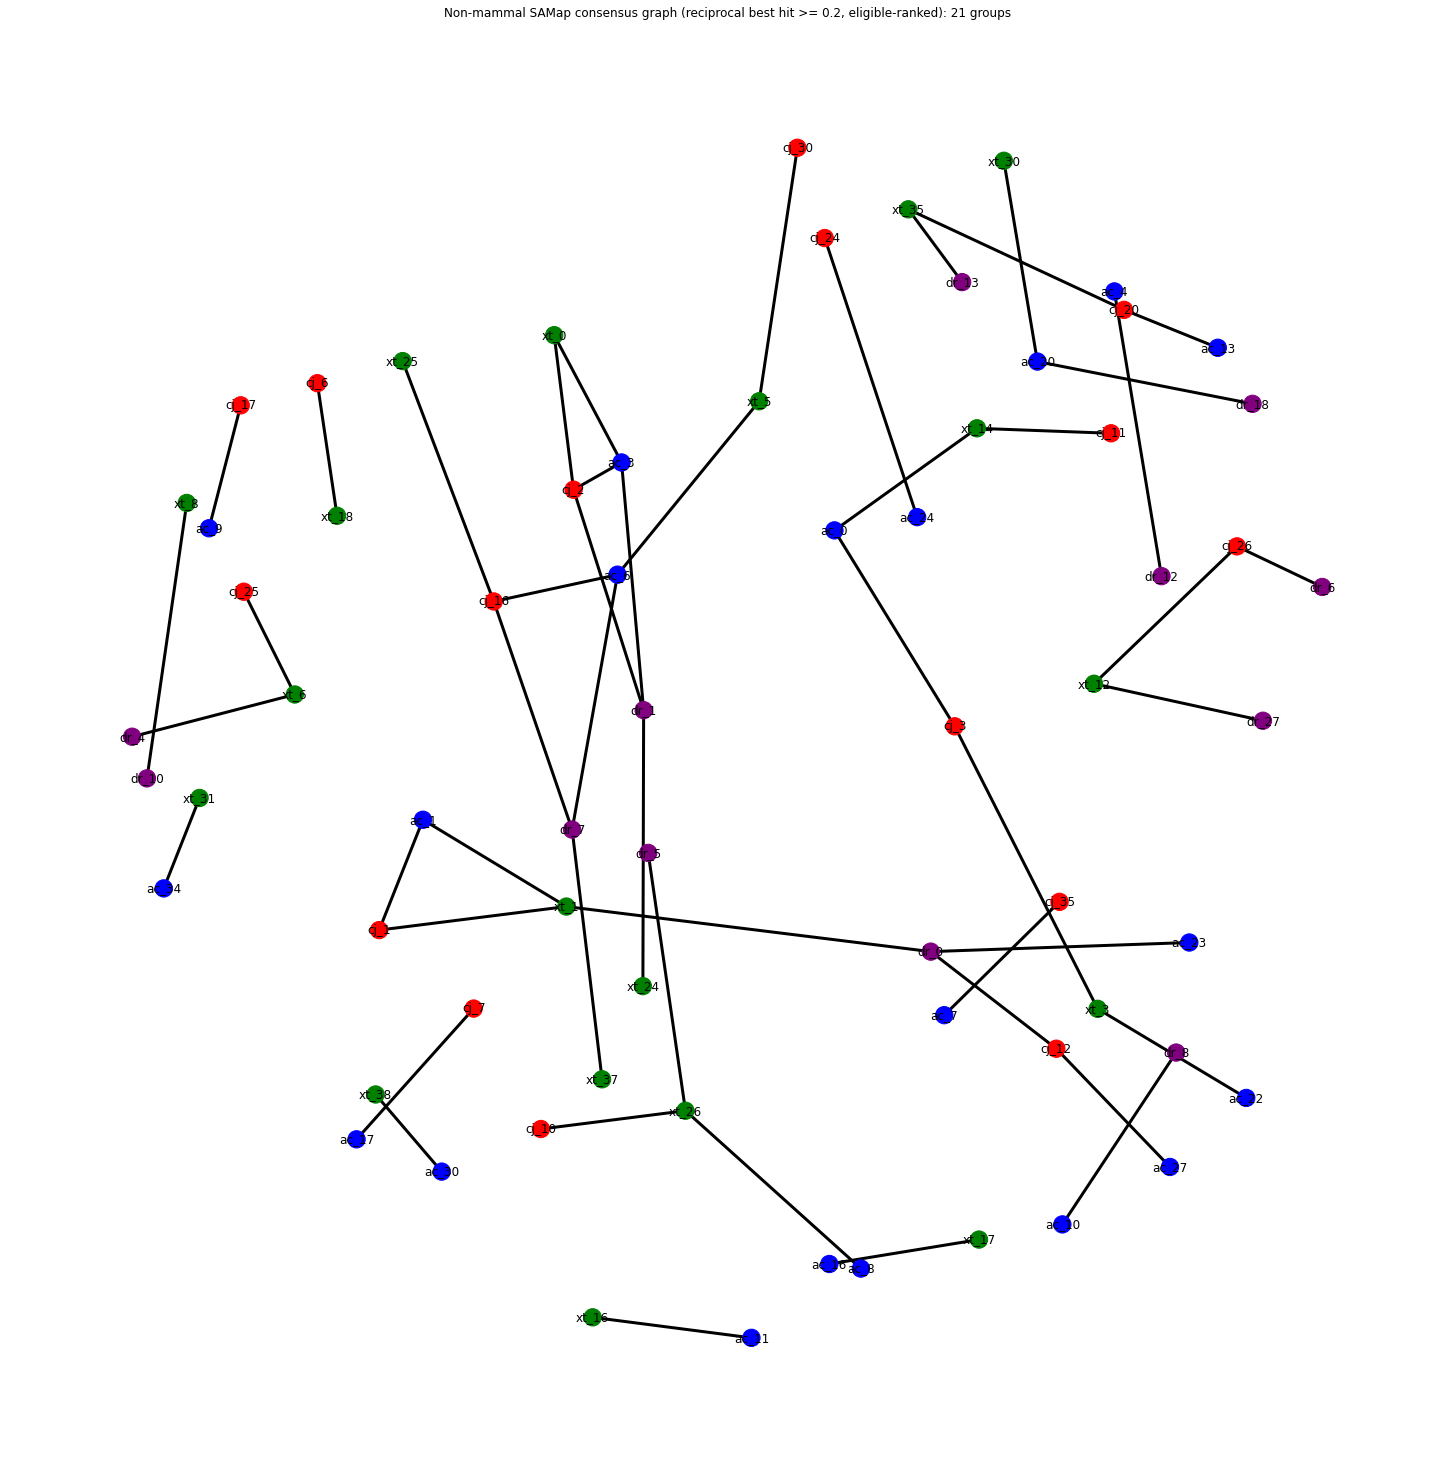

In [16]:
H = G.subgraph([n for n in G if G.degree(n) > 0])
pos = nx.spring_layout(H, weight='weight', k=.6, iterations=100, seed=0)

plt.figure(figsize=(20, 20))
nx.draw(H, pos, with_labels=True, width=3, edge_color='black',
        node_color=[PREFIX_COLOR[node_species[n]] for n in H.nodes()])
plt.title(f'Non-mammal SAMap consensus graph (reciprocal best hit >= {THRESH}, '
          f'eligible-ranked): {len(members)} groups')
plt.savefig(f'nonmam_mappinggraph_SAMap_{DATE}.svg', bbox_inches='tight')
plt.show()

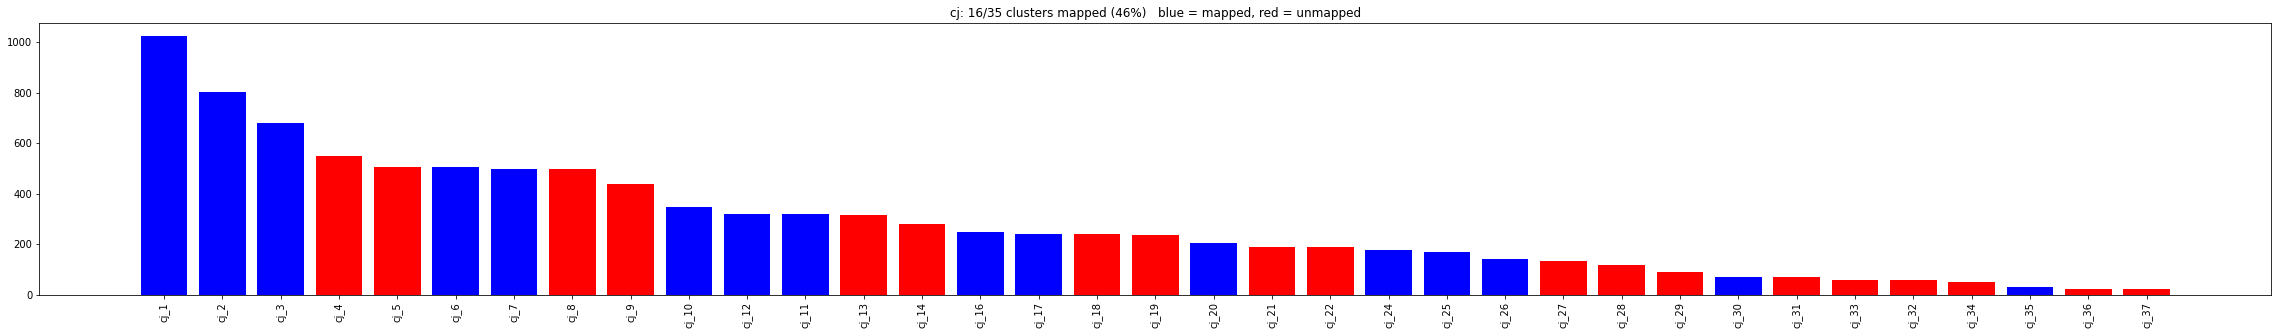

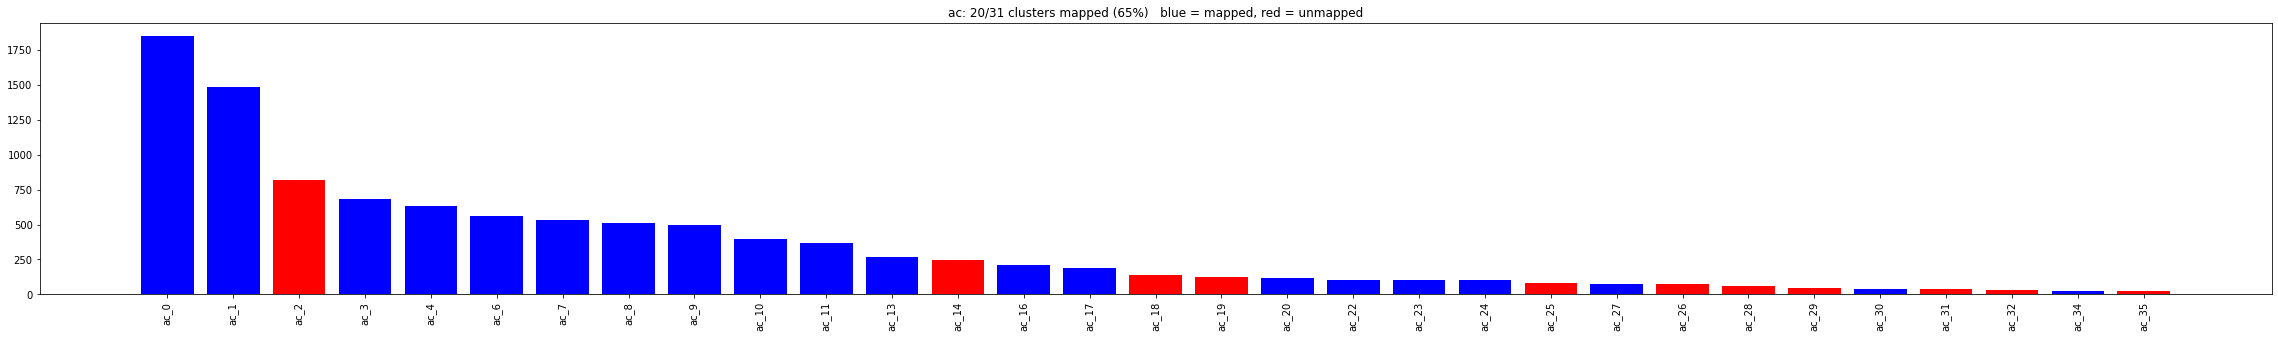

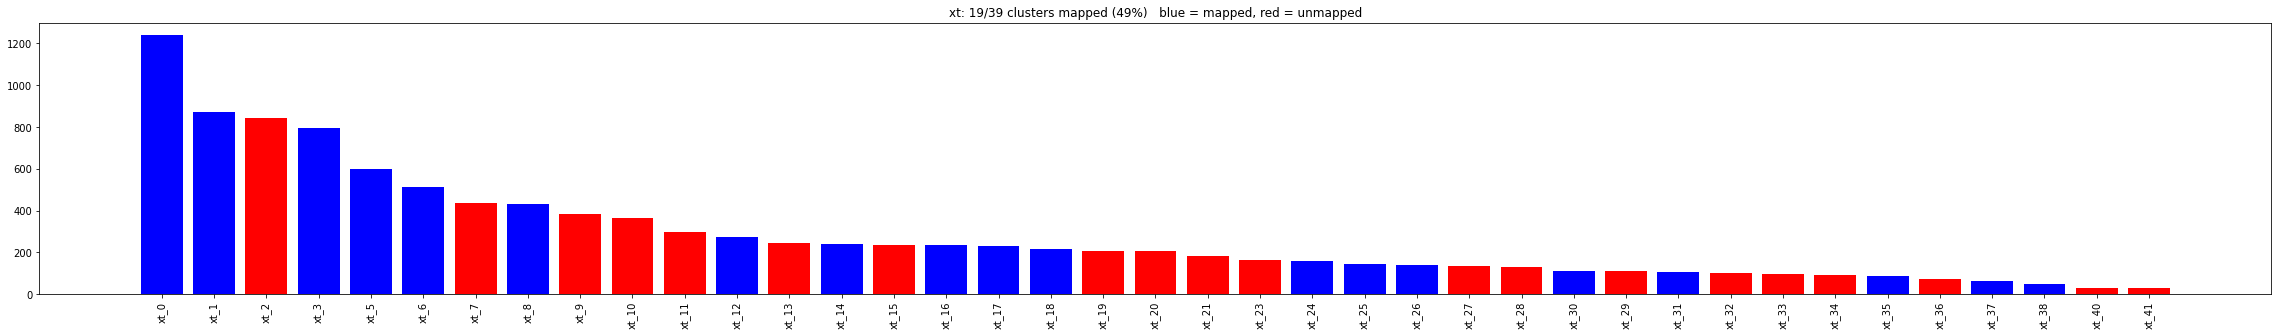

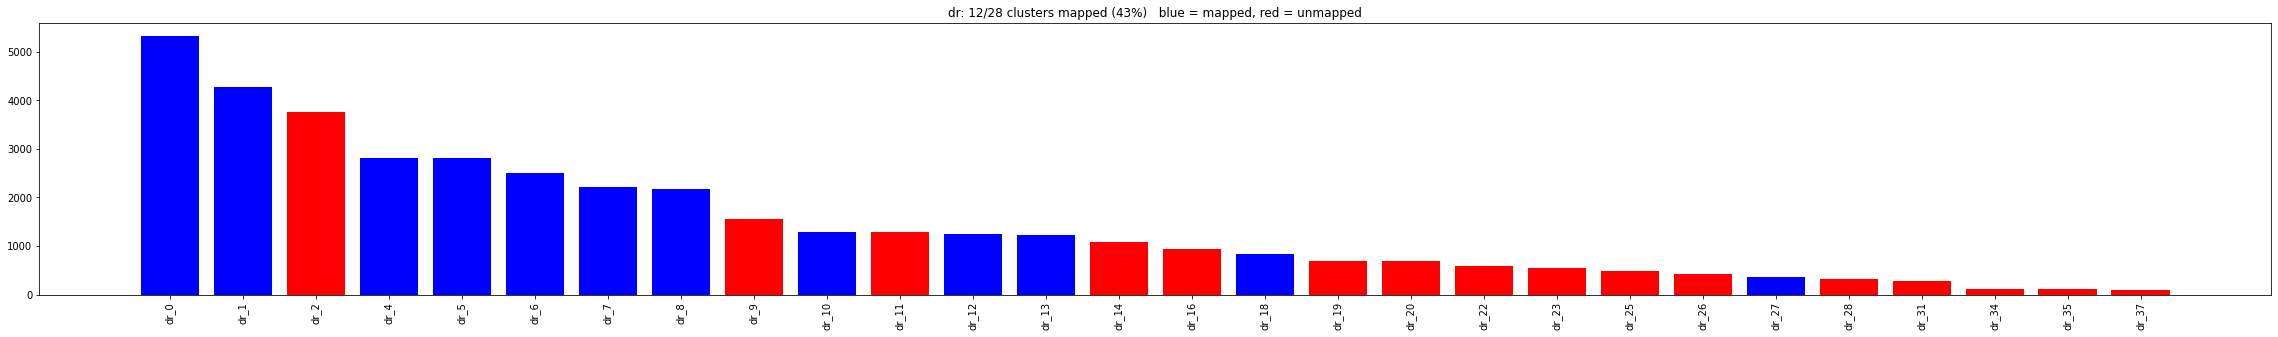

In [ ]:
for s in SPECIES:
    mapped = {n for n in G if node_species[n] == s and G.degree(n) > 0}
    rows = sorted(((cell_counts[n], n, 'blue' if n in mapped else 'red')
                   for n in node_species if node_species[n] == s), reverse=True)
    vals, names, cols = zip(*rows)

    plt.figure(figsize=(40, 5))
    plt.bar(x=names, height=vals, color=cols)
    plt.title(f'{s}: {len(mapped)}/{len(rows)} clusters mapped '
              f'({100*len(mapped)/len(rows):.0f}%)   blue = mapped, red = unmapped')
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
cov = []
for s in SPECIES:
    nodes = [n for n in node_species if node_species[n] == s]
    inn = [n for n in nodes if n in result]
    cov.append({'species': s, 'neuronal types': len(nodes), 'grouped': len(inn),
                'fraction': round(len(inn) / len(nodes), 3),
                'cells grouped': sum(cell_counts[n] for n in inn),
                'cells total': sum(cell_counts[n] for n in nodes)})
pd.DataFrame(cov).set_index('species')

,neuronal types,grouped,fraction,cells grouped,cells total
species,,,,,
cj,35,16,0.457,5778,9845
ac,31,20,0.645,8746,10431
xt,39,19,0.487,6519,10885
dr,28,12,0.429,27072,40047


In [19]:
def apply_labels(fn, s, dry_run=True):
    sam = SAM()
    sam.load_data(fn)

    src = sam.adata.obs[LEVEL].astype(str)
    fin = src.map(lambda x: result.get(x, x))

    print(f'{s}: {int((fin != src).sum())}/{len(src)} cells relabelled, '
          f'{src.nunique()} -> {fin.nunique()} distinct labels')
    print('    new labels:', sorted(set(fin) - set(src)))

    if dry_run:
        print('    dry run — nothing written')
        return sam

    sam.adata.obs[OUT_LEVEL] = pd.Categorical(fin.values)
    sam.save_anndata(fn)
    print(f'    saved {OUT_LEVEL} into {fn}')
    return sam

In [20]:
# Flip to dry_run=False to commit. Overwrites the four h5ads.
for s in SPECIES:
    apply_labels(H5AD[s], s, dry_run=False)
    gc.collect()

cj: 5778/74758 cells relabelled, 139 -> 136 distinct labels
    new labels: ['cj_ac_1', 'cj_ac_2', 'cj_ac_3', 'cj_ac_4', 'cj_ac_xt_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_3', 'cj_ac_xt_dr_4', 'cj_ac_xt_dr_5', 'cj_xt_1', 'cj_xt_dr_1', 'cj_xt_dr_2']
    saved ss_subclass_nounlabeled_nmm_v4_nn into Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad
ac: 8746/47900 cells relabelled, 131 -> 128 distinct labels
    new labels: ['ac_dr_1', 'ac_dr_2', 'ac_xt_1', 'ac_xt_2', 'ac_xt_3', 'ac_xt_4', 'ac_xt_dr_1', 'cj_ac_1', 'cj_ac_2', 'cj_ac_3', 'cj_ac_4', 'cj_ac_xt_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_3', 'cj_ac_xt_dr_4', 'cj_ac_xt_dr_5']
    saved ss_subclass_nounlabeled_nmm_v4_nn into Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad
xt: 6519/42221 cells relabelled, 122 -> 118 distinct labels
    new labels: ['ac_xt_1', 'ac_xt_2', 'ac_xt_3', 'ac_xt_4', 'ac_xt_dr_1', 'cj_ac_xt_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_3', 'cj_ac_xt_dr_4', 'cj_ac_xt_d